/tmp/ipykernel_2315/916373043.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


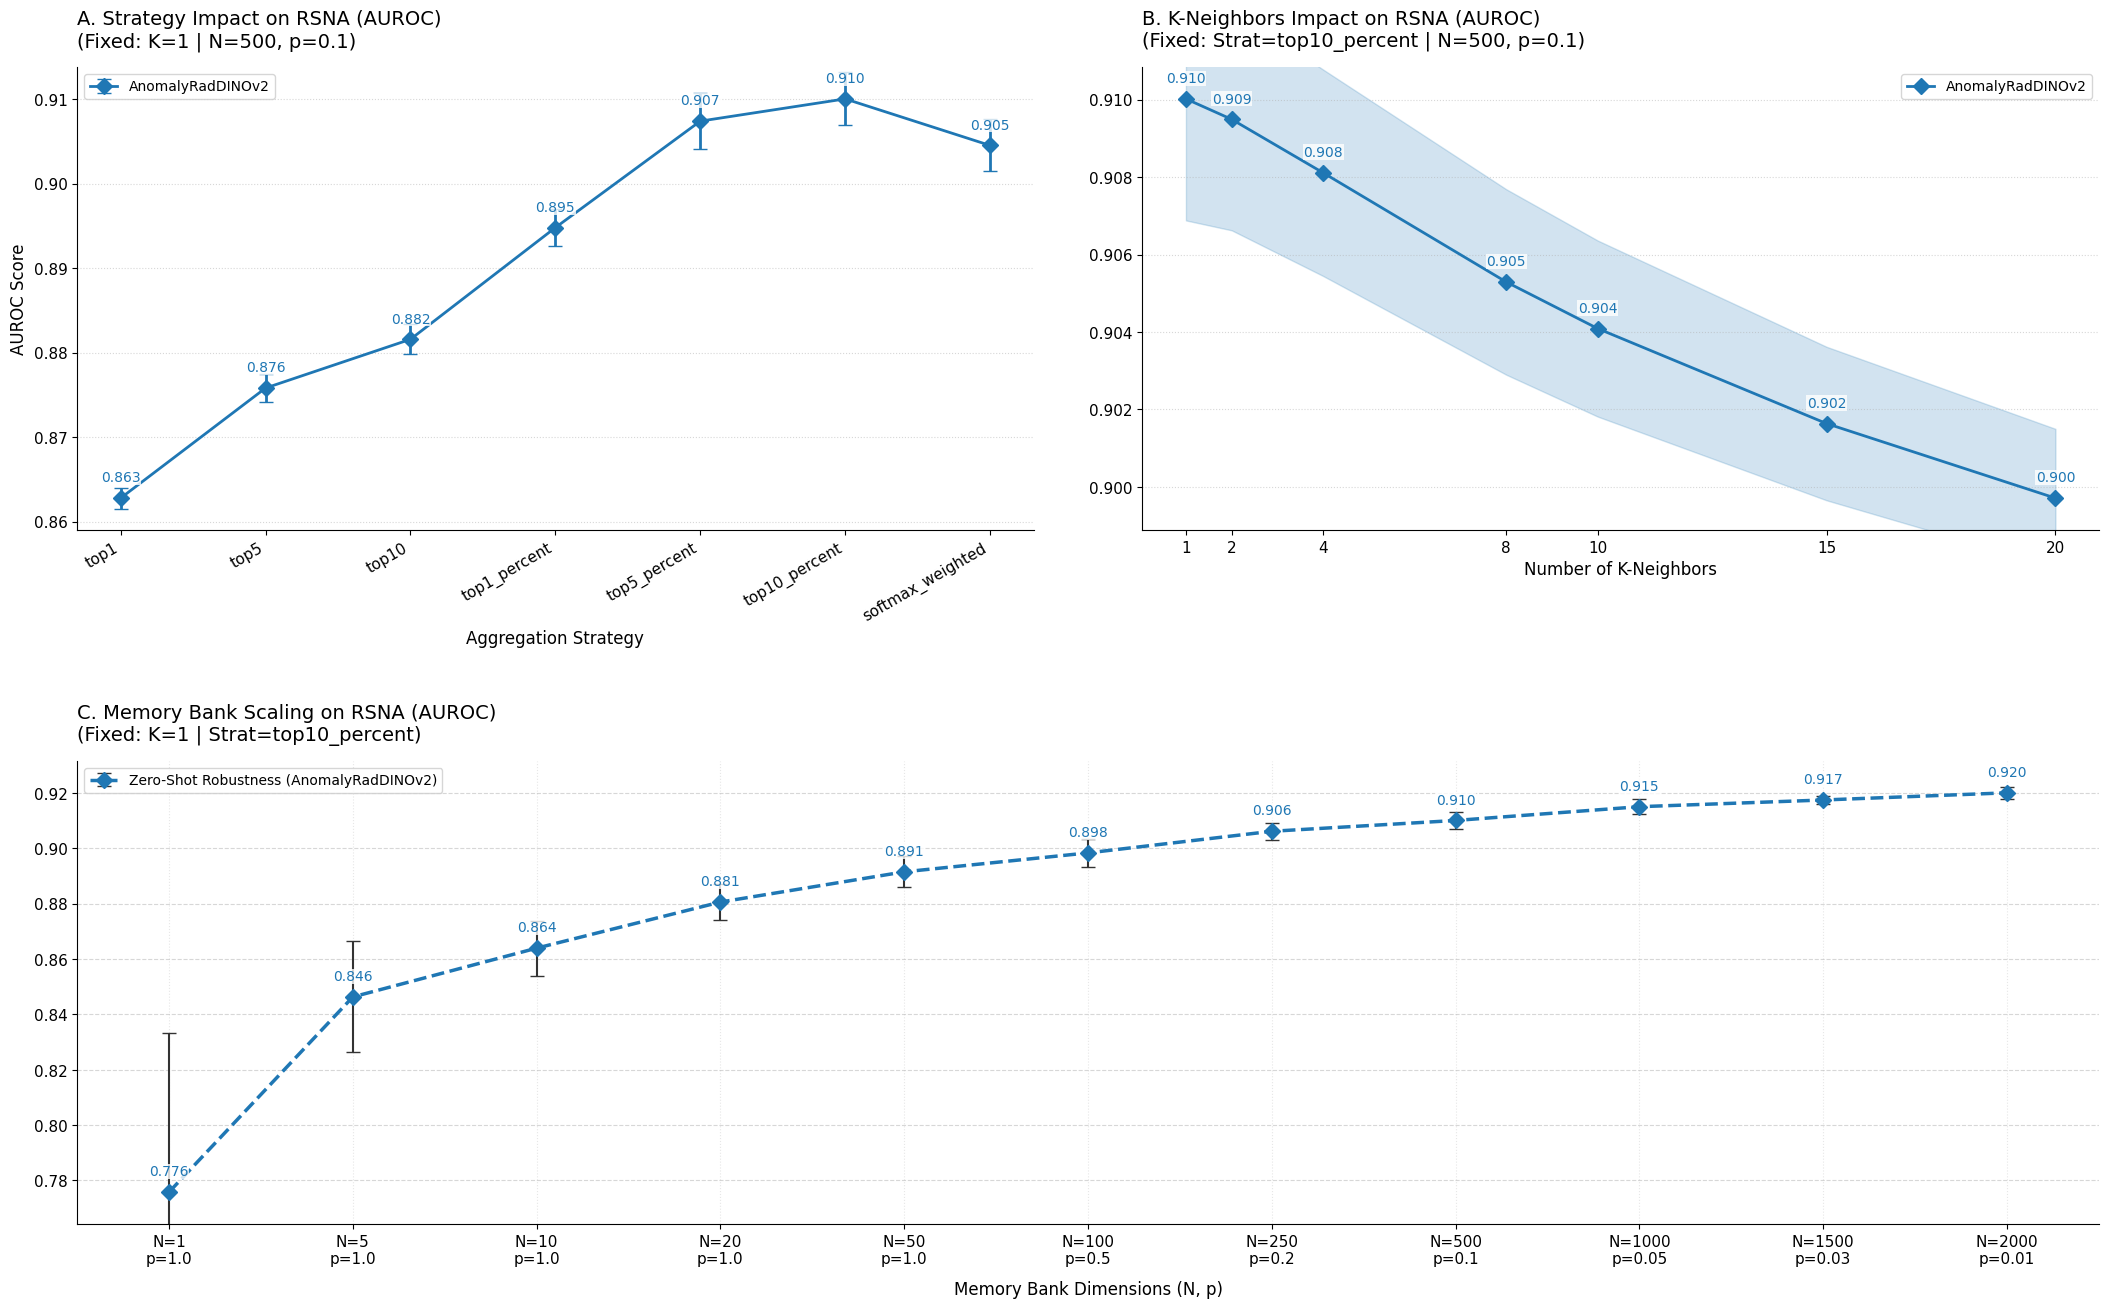

/tmp/ipykernel_2315/916373043.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


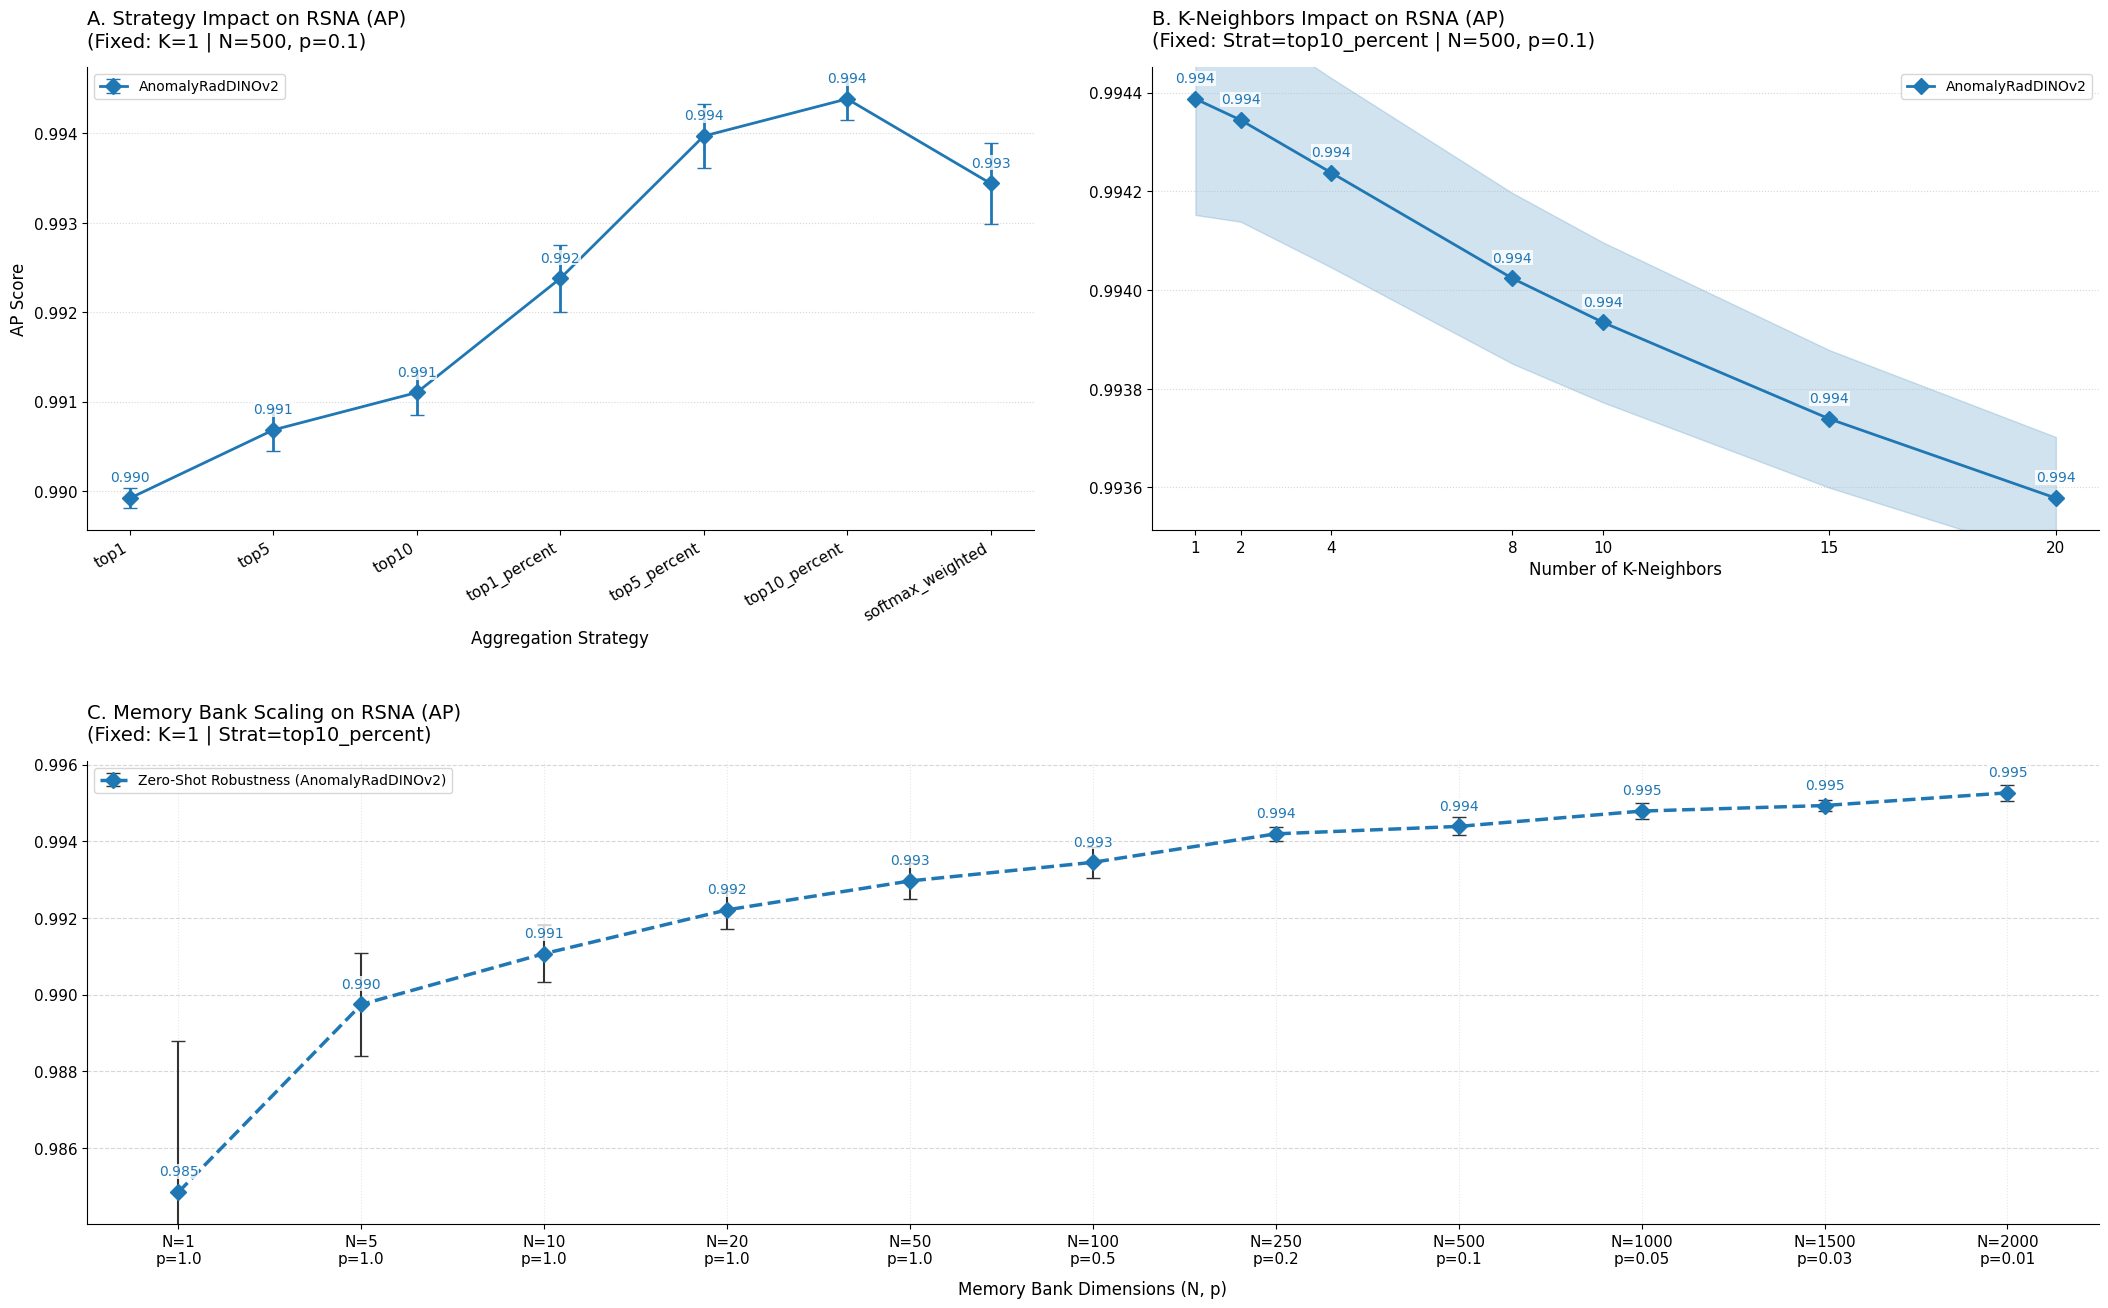

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

# ==========================================
# 1. CONFIGURATIONS & MAPPINGS
# ==========================================
ROOT_DIR = '/home/ca_uop_muoi/Applications/graduate_thesis/notebook/anomaly_detection/benchmarking/bmad/rsna'

# Ở Notebook này chỉ tồn tại duy nhất model V2 chạy trên 2 bộ data (v1, v2)
data_versions = ['v1/aamb', 'v2/aamb', 'v3/aamb', 'v4/aamb', 'v5/aamb']

case_info = {
    '8':  {'N': 1,    'p': 1.0},
    '9':  {'N': 5,    'p': 1.0},
    '10': {'N': 10,   'p': 1.0},
    '11': {'N': 20,   'p': 1.0},
    '1':  {'N': 50,   'p': 1.0}, 
    '2':  {'N': 100,  'p': 0.5}, 
    '3':  {'N': 250,  'p': 0.2}, 
    '4':  {'N': 500,  'p': 0.1}, 
    '5':  {'N': 1000, 'p': 0.05}, 
    '6':  {'N': 1500, 'p': 0.03}, 
    '7':  {'N': 2000, 'p': 0.01}
}

k_values = [1, 2, 4, 8, 10, 15, 20]
strategies = ["top1", "top5", "top10", "top1_percent", "top5_percent", "top10_percent", "softmax_weighted"]

# Cấu hình "nền tảng" (Slicing Plane) để vẽ biểu đồ
FIXED_STRAT = 'top10_percent'
FIXED_K = 1
FIXED_CASE = '4' 

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.titlesize': 14, 'axes.titleweight': 'normal',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 11
})

color_theme = '#1f77b4' # Xanh dương đặc trưng cho phiên bản V2 (AAMB)

# ==========================================
# 2. DATA EXTRACTION & AGGREGATION
# ==========================================

def calc_variation(x):
    """
    Tính toán độ dao động tùy theo số lượng seed thu thập được.
    - Nếu n = 2: Dùng Độ chênh bán phần (Max - Min) / 2
    - Nếu n > 2 (VD: 5 seeds): Dùng Độ lệch chuẩn mẫu (Sample Std, ddof=1)
    """
    n = len(x)
    if n <= 1:
        return 0.0
    elif n == 2:
        return (np.max(x) - np.min(x)) / 2.0
    else:
        # ddof=1 là chuẩn cho Sample Standard Deviation khi n khiêm tốn (như n=5)
        return np.std(x, ddof=1)
    
    
def load_bmad_rsna_benchmarks():
    raw_results = []
    available_cases = ['8', '9', '10', '11', '1', '2', '3', '4', '5', '6', '7']
    
    for cid in available_cases:
        cfile = f'inference_case_{cid}.npz'
        
        for dv in data_versions:
            path = os.path.join(ROOT_DIR, dv, cfile) # Thư mục BMAD RSNA không còn folder model, trực tiếp chia data_v1 / data_v2
            if not os.path.exists(path): continue
                
            data = np.load(path)
            y_true = data['true_labels']
            
            for k in k_values:
                for strat in strategies:
                    key = f"k_{k}_{strat}"
                    if key in data:
                        y_score = data[key]
                        raw_results.append({
                            'Data_Version': dv,
                            'Case_ID': cid,
                            'N': case_info[cid]['N'],
                            'p': case_info[cid]['p'],
                            'K': k, 
                            'Strategy': strat,
                            'AUROC': roc_auc_score(y_true, y_score),
                            'AP': average_precision_score(y_true, y_score)
                        })
    return pd.DataFrame(raw_results)

df_raw = load_bmad_rsna_benchmarks()

df_raw
df_raw['Strategy'] = pd.Categorical(df_raw['Strategy'], categories=strategies, ordered=True)

df_agg = df_raw.groupby(['Case_ID', 'N', 'p', 'K', 'Strategy'], observed=True).agg(
    AUROC_mean=('AUROC', 'mean'), AUROC_std=('AUROC', calc_variation),
    AP_mean=('AP', 'mean'), AP_std=('AP', calc_variation)
).reset_index().fillna(0)

# Sort trục N chuẩn logic
df_agg = df_agg.sort_values(by=['N', 'K', 'Strategy'])

# ==========================================
# 3. PLOTTING FUNCTIONS
# ==========================================
def set_ylim_tight(ax, y_values, margin_factor=0.08):
    if len(y_values) == 0: return
    lb, ub = np.min(y_values), np.max(y_values)
    ran = ub - lb if (ub - lb) > 0 else 0.01
    ax.set_ylim(max(0, lb - ran*margin_factor), min(1, ub + ran*margin_factor))

def annotate_point(ax, x, y, color):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 12), 
                ha='center', fontsize=10, color=color, weight='normal',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.5))

# PLOT A: Slicing by Strategy
def draw_vs_strategy(ax, metric, letter):
    m_mean, m_std = f'{metric}_mean', f'{metric}_std'
    st_data = df_agg[(df_agg['Case_ID'] == FIXED_CASE) & (df_agg['K'] == FIXED_K)]
    
    if not st_data.empty:
        ax.errorbar(st_data['Strategy'], st_data[m_mean], yerr=st_data[m_std], 
                    fmt='D', color=color_theme, ls='-', lw=2, capsize=5, ms=8, label="AnomalyRadDINOv2")
        
        for x, y in zip(st_data['Strategy'], st_data[m_mean]):
            annotate_point(ax, x, y, color_theme)
            
        all_y = st_data[m_mean].tolist()
        set_ylim_tight(ax, all_y)
        
    ax.set_title(f'{letter}. Strategy Impact on RSNA ({metric})\n(Fixed: K={FIXED_K} | N={case_info[FIXED_CASE]["N"]}, p={case_info[FIXED_CASE]["p"]})', pad=15)
    ax.set_xlabel('Aggregation Strategy')
    ax.set_ylabel(f'{metric} Score')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(loc='best')
    ax.grid(axis='y', ls=':', alpha=0.5)

# PLOT B: Slicing by K-Neighbors
def draw_vs_k(ax, metric, letter):
    m_mean, m_std = f'{metric}_mean', f'{metric}_std'
    k_data = df_agg[(df_agg['Case_ID'] == FIXED_CASE) & (df_agg['Strategy'] == FIXED_STRAT)]
    
    if not k_data.empty:
        ax.plot(k_data['K'], k_data[m_mean], marker='D', color=color_theme, ls='-', lw=2, ms=8, label="AnomalyRadDINOv2")
        ax.fill_between(k_data['K'], k_data[m_mean] - k_data[m_std], k_data[m_mean] + k_data[m_std], color=color_theme, alpha=0.2)
        
        for x, y in zip(k_data['K'], k_data[m_mean]):
            annotate_point(ax, x, y, color_theme)

        all_y = k_data[m_mean].tolist()
        set_ylim_tight(ax, all_y)
        
    ax.set_title(f'{letter}. K-Neighbors Impact on RSNA ({metric})\n(Fixed: Strat={FIXED_STRAT} | N={case_info[FIXED_CASE]["N"]}, p={case_info[FIXED_CASE]["p"]})', pad=15)
    ax.set_xlabel('Number of K-Neighbors')
    ax.set_xticks(k_values)
    ax.legend(loc='best')
    ax.grid(axis='y', ls=':', alpha=0.5)

# PLOT C: Slicing by Scaling Behavior
def draw_vs_scale(ax, metric, letter):
    m_mean, m_std = f'{metric}_mean', f'{metric}_std'
    n_data = df_agg[(df_agg['K'] == FIXED_K) & (df_agg['Strategy'] == FIXED_STRAT)]
    
    unique_n = np.sort(df_agg['N'].unique())
    x_positions = np.arange(len(unique_n))
    n_to_x = {n: i for i, n in enumerate(unique_n)}
    
    if not n_data.empty:
        mapped_x = n_data['N'].map(n_to_x)
        ax.errorbar(mapped_x, n_data[m_mean], yerr=n_data[m_std], 
                    fmt='D', color=color_theme, ls='--', lw=2.5, capsize=5, ms=8, ecolor='#333333', elinewidth=1.5,
                    label="Zero-Shot Robustness (AnomalyRadDINOv2)")
        
        for x, y in zip(mapped_x, n_data[m_mean]):
            annotate_point(ax, x, y, color_theme)
            
        all_y = n_data[m_mean].tolist()
        set_ylim_tight(ax, all_y)
        
    ax.set_title(f'{letter}. Memory Bank Scaling on RSNA ({metric})\n(Fixed: K={FIXED_K} | Strat={FIXED_STRAT})', pad=15)
    
    x_labels = []
    for n_val in unique_n:
        p_val = df_agg[df_agg['N'] == n_val]['p'].iloc[0]
        x_labels.append(f"N={n_val}\np={p_val}")
        
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_xlabel('Memory Bank Dimensions (N, p)', labelpad=10)
    ax.legend(loc='best')
    ax.grid(axis='y', ls='--', alpha=0.5)
    ax.grid(axis='x', ls=':', alpha=0.3)

# ==========================================
# 4. RENDER PLOTS
# ==========================================
# -- FIGURE 1: AUROC --
fig_auroc = plt.figure(figsize=(22, 14))
gs = fig_auroc.add_gridspec(2, 2)
ax1 = fig_auroc.add_subplot(gs[0, 0]); draw_vs_strategy(ax1, 'AUROC', 'A')
ax2 = fig_auroc.add_subplot(gs[0, 1]); draw_vs_k(ax2, 'AUROC', 'B')
ax3 = fig_auroc.add_subplot(gs[1, :]); draw_vs_scale(ax3, 'AUROC', 'C')
plt.tight_layout(pad=4.0) 
plt.show()

# -- FIGURE 2: AP --
fig_ap = plt.figure(figsize=(22, 14))
gs_ap = fig_ap.add_gridspec(2, 2)
ax4 = fig_ap.add_subplot(gs_ap[0, 0]); draw_vs_strategy(ax4, 'AP', 'A')
ax5 = fig_ap.add_subplot(gs_ap[0, 1]); draw_vs_k(ax5, 'AP', 'B')
ax6 = fig_ap.add_subplot(gs_ap[1, :]); draw_vs_scale(ax6, 'AP', 'C')
plt.tight_layout(pad=4.0)
plt.show()

In [2]:
def replace_value(val):
    if (val == 'v1/aamb'):
        return "v1"
    elif (val == 'v2/aamb'):
        return "v2"
    elif (val == 'v3/aamb'):
        return "v3"
    elif (val == 'v4/aamb'):
        return "v4"
    elif (val == 'v5/aamb'):
        return "v5"

df_raw['Data_Version'] = df_raw['Data_Version'].apply(replace_value)
df_raw

,Data_Version,Case_ID,N,p,K,Strategy,AUROC,AP
0,v1,8,1,1.00,1,top1,0.773817,0.982512
1,v1,8,1,1.00,1,top5,0.772895,0.982204
2,v1,8,1,1.00,1,top10,0.774896,0.982133
3,v1,8,1,1.00,1,top1_percent,0.785833,0.982640
4,v1,8,1,1.00,1,top5_percent,0.818925,0.986952
...,...,...,...,...,...,...,...,...
1955,v2,7,2000,0.01,20,top10,0.846993,0.988973
1956,v2,7,2000,0.01,20,top1_percent,0.877259,0.991445
1957,v2,7,2000,0.01,20,top5_percent,0.896789,0.993418
1958,v2,7,2000,0.01,20,top10_percent,0.900590,0.993862


In [ ]:
# Xác định các cột dùng để nhóm
group_cols = ['Case_ID', 'N', 'p', 'K', 'Strategy']

# Groupby và tính mean, std cho AUROC và AP
summary_table = df_raw.groupby(group_cols)[['AUROC', 'AP']].agg(['mean', 'std']).reset_index()

# Lúc này các cột sẽ có dạng MultiIndex (ví dụ: ('AUROC', 'mean')). 
# Ta cần làm phẳng (flatten) tên cột lại để dễ thao tác:
summary_table.columns = [
    f"{col[0]}_{col[1].capitalize()}" if col[1] != "" else col[0] 
    for col in summary_table.columns
]

# Sắp xếp dữ liệu theo N tăng dần và Case_ID (như yêu cầu trước đó)
summary_table = summary_table.sort_values(by=['N', 'Case_ID']).reset_index(drop=True)

# Lọc lại danh sách các cột cần hiển thị và theo đúng thứ tự
cols_order = ['Case_ID', 'N', 'p', 'K', 'Strategy', 
              'AUROC_Mean', 'AUROC_Std', 
              'AP_Mean', 'AP_Std']
summary_table = summary_table[cols_order]

# Tùy chọn: Format hiển thị 4 chữ số thập phân nếu bạn muốn in ra bằng thư viện style
styled_table = summary_table.style.format({
    col: "{:.4f}" for col in summary_table.columns if 'AUROC' in col or 'AP' in col
}).set_caption("Tổng hợp Mean và Std của AUROC, AP theo các kịch bản")

summary_table.to_csv("bmad_rsna_benchmarks_summary.csv", index=False)

In [4]:
df_raw.to_csv("bmad_rsna_benchmarks_raw.csv", index=False)